# Проект. Вариант 2

**A/B-тестирование · SQL · Python**

**Итог A/B-теста:** массовый запуск новой механики оплаты по этим данным не рекомендован.
Рост выручки на активного пользователя статистически не подтверждён.
Ниже приведены расчёты, проверка устойчивости результата, SQL-запрос и функции автоматизации.

Для повторного запуска: расположить четыре CSV в папке `data` рядом с notebook и выполнить
**Kernel → Restart & Run All**. Поддерживаются и исходные имена файлов с префиксом `Проект_2_`.
Денежные показатели приведены в единицах исходного поля `rev`: валюта в задании не указана.

In [1]:
from pathlib import Path
import csv
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy import stats

ALPHA = 0.05
SEED = 42
N_BOOTSTRAP = 20_000
COLORS = {"A": "#537A99", "B": "#DE8054"}

pd.set_option("display.max_columns", 12)
pd.set_option("display.max_rows", 20)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 10,
                     "figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False})

def find_data_file(*names):
    for folder in [Path("data"), Path("."), Path("upload")]:
        for name in names:
            candidate = folder / name
            if candidate.is_file():
                return candidate
    raise FileNotFoundError(f"Не найден CSV: {names}. Поместите его в папку data.")

paths = {
    "groups": find_data_file("groups.csv", "Проект_2_groups.csv"),
    "additional": find_data_file("groups_add.csv", "group_add.csv", "Проект_2_group_add.csv"),
    "active": find_data_file("active_studs.csv", "Проект_2_active_studs.csv"),
    "checks": find_data_file("checks.csv", "Проект_2_checks.csv"),
}
print(f"Python {sys.version.split()[0]}; pandas {pd.__version__}; "
      f"NumPy {np.__version__}; SciPy {scipy.__version__}")

Python 3.12.14; pandas 2.2.3; NumPy 2.3.5; SciPy 1.17.0


## Задание 1. A/B-тестирование

### 1.1. Цель и правила анализа

Группа **A** использовала базовую механику оплаты, группа **B** — новую.
Единица наблюдения и статистического сравнения — **пользователь**.

Основной расчёт проводится по посетителям из `active_studs.csv`: они могли увидеть механику
во время эксперимента. Такое ограничение допустимо для причинного вывода только при условии,
что попадание в список активных не зависит от варианта оплаты. Это предположение проверяем
настолько, насколько позволяют данные; дополнительно анализируем всех назначенных пользователей.

| Метрика | Расчёт | Назначение |
|---|---|---|
| **ARPU, основная** | Выручка / все пользователи анализируемой выборки | Совместно учитывает оплату и её размер |
| **CR, диагностическая** | Пользователи с `rev > 0` / все пользователи выборки | Показывает долю оплативших |
| **ARPPU, диагностическая** | Выручка / пользователи с `rev > 0` | Помогает объяснить изменение ARPU |

Неоплатившим пользователям присваивается нулевая выручка. Общую выручку напрямую не сравниваем:
размеры групп отличаются. Для одной и той же выборки выполняется **ARPU = CR × ARPPU**.
ARPPU рассчитан на подмножестве, которое может меняться под действием эксперимента, поэтому
его рост сам по себе не доказывает полезность новой механики для всех пользователей.

### 1.2. Загрузка и проверка исходных данных

In [2]:
# В основных файлах групп и оплат используется ';', в дополнении — ','.
raw = {
    "groups": pd.read_csv(paths["groups"], sep=";"),
    "additional": pd.read_csv(paths["additional"], sep=","),
    "active": pd.read_csv(paths["active"], sep=","),
    "checks": pd.read_csv(paths["checks"], sep=";"),
}

quality = pd.DataFrame([
    {"Файл": name, "Строк": len(frame), "Столбцов": frame.shape[1],
     "Пропусков": int(frame.isna().sum().sum()),
     "Повторов строк": int(frame.duplicated().sum()),
     "Повторов ID": int(frame.iloc[:, 0].duplicated().sum())}
    for name, frame in raw.items()
]).set_index("Файл")
display(quality)

groups = raw["groups"].copy()
additional = raw["additional"].copy()
active = raw["active"].rename(columns={"student_id": "id"})
checks = raw["checks"].rename(columns={"student_id": "id"})

assert all(not frame.isna().any().any() for frame in raw.values())
assert groups["grp"].isin(["A", "B"]).all()
assert additional["grp"].isin(["A", "B"]).all()
assert np.isfinite(checks["rev"]).all() and checks["rev"].ge(0).all()
assert all(pd.api.types.is_integer_dtype(frame["id"])
           and frame["id"].gt(0).all() for frame in [groups, additional, active, checks])

,Строк,Столбцов,Пропусков,Повторов строк,Повторов ID
Файл,,,,,
groups,74484,2,0,0,0
additional,92,2,0,0,0
active,8341,1,0,0,0
checks,541,2,0,0,0


В исходных файлах нет пропусков, повторов строк и повторов ID.
`groups` содержит 74 484 пользователя, дополнительный файл — 92,
`active_studs` — 8 341, `checks` — 541 пользователя с оплатой.
Ниже объединяем назначения и предотвращаем увеличение числа строк при присоединении оплат.

In [3]:
def combine_groups(groups, additional=None):
    """Объединить назначения; повторы того же назначения не увеличивают выборку."""
    parts = [groups] if additional is None else [groups, additional]
    combined = pd.concat(parts, ignore_index=True)
    conflicts = combined.groupby("id")["grp"].nunique()
    conflicts = conflicts[conflicts > 1]
    if not conflicts.empty:
        raise ValueError(f"Пользователи назначены в обе группы: {conflicts.index[:5].tolist()}")
    return combined.drop_duplicates("id").reset_index(drop=True)


def build_user_data(groups, active, checks, cohort="active", unknown_users="raise"):
    """Одна строка на пользователя; cohort='active' или 'all'."""
    if cohort not in {"active", "all"}:
        raise ValueError("cohort должен быть 'active' или 'all'.")
    if unknown_users not in {"raise", "exclude"}:
        raise ValueError("unknown_users должен быть 'raise' или 'exclude'.")
    groups = combine_groups(groups)
    active = active.drop_duplicates("id")
    # Несколько строк оплат одного пользователя суммируются, а не размножают JOIN.
    # Без идентификатора транзакции нельзя отличить две одинаковые оплаты от дубля.
    payments = checks.groupby("id", as_index=False)["rev"].sum()
    unknown_active = active.loc[~active["id"].isin(groups["id"]), "id"]
    unknown_checks = payments.loc[~payments["id"].isin(groups["id"]), "id"]
    if unknown_users == "raise" and (len(unknown_active) or len(unknown_checks)):
        raise ValueError(
            f"Неизвестная группа: активных {len(unknown_active)}, "
            f"пользователей с оплатами {len(unknown_checks)}. Проверьте дополнительный файл."
        )
    data = groups.copy()
    data["active"] = data["id"].isin(active["id"])
    if cohort == "active":
        data = data.loc[data["active"]].copy()
    data = data.merge(payments, on="id", how="left", validate="one_to_one")
    # Только отсутствие записи об оплате заменяется нулевой выручкой.
    data["rev"] = data["rev"].fillna(0.0)
    data["paid"] = data["rev"] > 0
    inactive_payments = payments.loc[
        ~payments["id"].isin(active["id"]) & payments["rev"].gt(0)
    ]
    audit = {
        "assigned_users": len(groups),
        "active_users_in_file": len(active),
        "cohort_users": len(data),
        "unknown_active_users": len(unknown_active),
        "unknown_payment_users": len(unknown_checks),
        "paying_users_outside_active": len(inactive_payments),
        "revenue_outside_active": float(inactive_payments["rev"].sum()),
    }
    return data.reset_index(drop=True), audit


def calculate_metrics(data):
    """CR — доля оплативших; ARPU — на пользователя; ARPPU — на платящего."""
    metrics = data.groupby("grp").agg(
        users=("id", "size"), payers=("paid", "sum"), revenue=("rev", "sum")
    ).reindex(["A", "B"])
    metrics[["users", "payers", "revenue"]] = metrics[
        ["users", "payers", "revenue"]
    ].fillna(0)
    metrics[["users", "payers"]] = metrics[["users", "payers"]].astype(int)
    users = metrics["users"].replace(0, np.nan)
    payers = metrics["payers"].replace(0, np.nan)
    metrics["cr"] = metrics["payers"] / users
    metrics["arpu"] = metrics["revenue"] / users
    metrics["arppu"] = metrics["revenue"] / payers
    return metrics

In [4]:
groups_all = combine_groups(groups, additional)
users, audit = build_user_data(groups_all, active, checks, cohort="active")

membership = pd.DataFrame({
    "Исходный файл": groups.groupby("grp").size(),
    "Дополнение": additional.groupby("grp").size(),
    "Всего назначено": groups_all.groupby("grp").size(),
    "Активных": users.groupby("grp").size(),
})
display(membership)

print("Пересечение основного и дополнительного файлов:",
      len(set(groups["id"]) & set(additional["id"])))
print("Активных пользователей без группы:", audit["unknown_active_users"])
print("Пользователей с оплатой без группы:", audit["unknown_payment_users"])
assert len(users) == active["id"].nunique()
assert users["id"].is_unique

# Сохраняем неоплативших: иначе невозможно корректно рассчитать CR и ARPU.
expected_payers = checks.loc[checks["id"].isin(active["id"]) & checks["rev"].gt(0), "id"].nunique()
assert users["paid"].sum() == expected_payers
assert users.loc[~users["paid"], "rev"].eq(0).all()

,Исходный файл,Дополнение,Всего назначено,Активных
grp,,,,
A,14671,22,14693,1538
B,59813,70,59883,6803


Пересечение основного и дополнительного файлов: 0
Активных пользователей без группы: 0
Пользователей с оплатой без группы: 0


Дополнительный файл полностью учтён: **92 новых назначения**, из них **13 активных пользователей**
(3 в A, 10 в B) и один плательщик в B. После объединения группа определена для всех активных
пользователей и всех пользователей с оплатами.

In [5]:
# Оплаты вне списка активных не объявляем ошибкой и не удаляем из исходных данных.
inactive_payments = checks.loc[~checks["id"].isin(active["id"])].merge(
    groups_all, on="id", how="left", validate="one_to_one"
)
inactive_summary = inactive_payments.groupby("grp").agg(
    Плательщиков=("id", "nunique"), Выручка=("rev", "sum")
)
display(inactive_summary)
print("Всего плательщиков вне active_studs:", len(inactive_payments))
print("Их выручка:", round(inactive_payments["rev"].sum(), 2))
assert len(inactive_payments) + users["paid"].sum() == checks["id"].nunique()
assert np.isclose(users["rev"].sum() + inactive_payments["rev"].sum(), checks["rev"].sum())

,Плательщиков,Выручка
grp,,
A,29,"19,276.0000"
B,120,"86,256.0001"


Всего плательщиков вне active_studs: 149
Их выручка: 105532.0


**149 плательщиков** (29 в A и 120 в B) с выручкой **105 532,00** отсутствуют в `active_studs`.
Причина из CSV не устанавливается: возможны автоматические списания, другой канал оплаты
или неполный журнал активности. Они не включаются в основной расчёт по посетителям,
но включаются в отдельный расчёт по всем назначениям в п. 1.7.

In [6]:
activity = groups_all.assign(is_active=groups_all["id"].isin(active["id"])).groupby("grp").agg(
    assigned=("id", "size"), active=("is_active", "sum")
)
activity["active_pct"] = activity["active"] / activity["assigned"] * 100
display(activity.rename(columns={"assigned": "Назначено", "active": "Активных",
                                  "active_pct": "Доля активных, %"}))

activity_table = np.column_stack([activity["active"], activity["assigned"] - activity["active"]])
activity_test = stats.chi2_contingency(activity_table, correction=False)
print(f"Диагностическая проверка активности: p = {activity_test.pvalue:.6f}")

,Назначено,Активных,"Доля активных, %"
grp,,,
A,14693,1538,10.4676
B,59883,6803,11.3605


Диагностическая проверка активности: p = 0.002089


В основной массе назначений доля A составляет около 19,7%, B — 80,3%.
Плановая пропорция распределения не дана, поэтому нельзя объявлять ошибку рандомизации,
сравнивая группы с произвольно выбранным соотношением 50/50 или 20/80.

Однако **доля активных различается**: 10,47% в A и 11,36% в B, диагностический `p = 0,00209`.
Это повод проверить отбор посетителей и логирование, а не доказательство конкретной ошибки.
Поэтому причинная интерпретация результата только среди активных ограничена.

### 1.3. Метрики по активным пользователям

In [7]:
metrics = calculate_metrics(users)

def present_metrics(frame):
    result = frame.copy()
    result["cr"] *= 100
    return result.rename(columns={"users": "Пользователи", "payers": "Плательщики",
                                  "revenue": "Выручка", "cr": "CR, %",
                                  "arpu": "ARPU", "arppu": "ARPPU"}).round(4)

display(present_metrics(metrics))
assert np.allclose(metrics["arpu"], metrics["cr"] * metrics["arppu"])

,Пользователи,Плательщики,Выручка,"CR, %",ARPU,ARPPU
grp,,,,,,
A,1538,78,"72,820.0000",5.0715,47.3472,933.5897
B,6803,314,"394,974.0035",4.6156,58.0588,"1,257.8790"


У B конверсия ниже на **0,456 процентного пункта** (−8,99% относительно A),
ARPU выше на **10,71** (+22,62%), ARPPU выше на **324,29** (+34,74%).
То есть в этой выборке увеличение суммы на платящего сопровождается меньшей долей оплативших.
Статистическую значимость оцениваем отдельно от размера наблюдаемого изменения.

### 1.4. Распределение оплат и возможные причины различий

,count,mean,std,min,25%,50%,75%,max
grp,,,,,,,,
A,78.0000,933.5900,919.9300,199.0000,290.0000,585.0000,"1,114.7500","3,660.0000"
B,314.0000,"1,257.8800",790.8600,199.0000,511.7500,"1,140.0000","1,900.0000","4,650.0000"


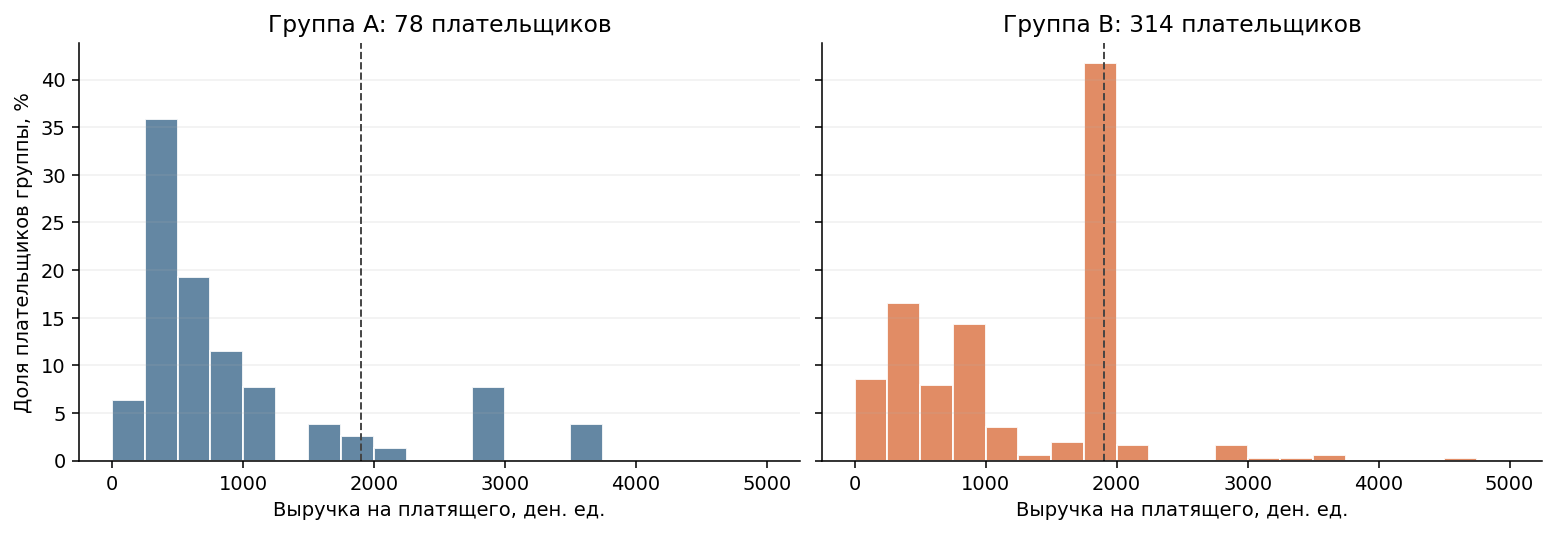

,Плательщиков,Плательщиков_с_rev_1900,"Доля плательщиков, %"
grp,,,
A,78,0,0.0000
B,314,128,40.7643


In [8]:
paying_users = users.loc[users["paid"]].copy()
display(paying_users.groupby("grp")["rev"].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.7), sharex=True, sharey=True,
                         constrained_layout=True)
bins = np.arange(0, 5001, 250)
for ax, group in zip(axes, ["A", "B"]):
    values = paying_users.loc[paying_users["grp"] == group, "rev"].to_numpy()
    ax.hist(values, bins=bins, weights=np.full(len(values), 100 / len(values)),
            color=COLORS[group], alpha=0.9, edgecolor="white")
    ax.axvline(1900, color="#444444", linestyle="--", linewidth=1)
    ax.set_title(f"Группа {group}: {len(values)} плательщиков")
    ax.set_xlabel("Выручка на платящего, ден. ед.")
    ax.grid(axis="y", alpha=0.18)
axes[0].set_ylabel("Доля плательщиков группы, %")
plt.show()

# 1900.0001 отличается от 1900 только точностью записи. В расчётах rev не округляем.
paying_users["near_1900"] = np.isclose(paying_users["rev"], 1900, rtol=0, atol=0.01)
price_peak = paying_users.groupby("grp").agg(
    Плательщиков=("id", "size"), Плательщиков_с_rev_1900=("near_1900", "sum")
)
price_peak["Доля плательщиков, %"] = price_peak["Плательщиков_с_rev_1900"] / price_peak["Плательщиков"] * 100
display(price_peak)

Распределения асимметричны. В B **128 из 314 плательщиков (40,76%)** имеют выручку около 1900;
на них приходится **61,57% выручки B**. В A таких значений нет. Медиана выручки плательщика:
585 в A и 1140 в B.

Различия могут быть связаны с конкретным тарифом, составом покупок или изменением выбора
продукта при новой механике. Информации о тарифах и заказах в этих четырёх CSV нет,
поэтому это гипотезы. Значения 1900 и крупные оплаты сохраняются: подтверждения ошибки нет.

### 1.5. Статистическая проверка

Для каждой метрики **H₀: показатель B равен показателю A**, **H₁: показатели различаются**.
Все тесты двусторонние, уровень значимости **α = 0,05**.

* **CR:** χ² Пирсона без поправки Йейтса для таблицы «группа × факт оплаты».
  Все ожидаемые частоты больше 5. Для разности долей используется 95% интервал
  на основе независимых стандартных ошибок.
* **ARPU и ARPPU:** t-тест Уэлча для разности средних, без предположения одинаковых дисперсий.
  Асимметрия исходной выручки не означает нормальность данных; устойчивость выводов
  дополнительно проверяется bootstrap по пользователям. Выборки платящих меньше,
  поэтому для ARPPU эта проверка особенно полезна.
* Для совместной интерпретации трёх метрик применяем **поправку Холма** к p-value.
  Показанные 95% интервалы индивидуальные и не являются одновременными интервалами для трёх метрик.

Метод Уэлча сравнивает именно средние: это соответствует определению денежных метрик.
Документация: [SciPy — ttest_ind](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html),
[SciPy — chi2_contingency](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2_contingency.html).

In [9]:
def holm_adjust(pvalues):
    """Поправка Холма для одной семьи проверяемых гипотез."""
    values = np.asarray(pvalues, dtype=float)
    order = np.argsort(values)
    adjusted = np.maximum.accumulate(values[order] * np.arange(len(values), 0, -1))
    result = np.empty_like(adjusted)
    result[order] = np.minimum(adjusted, 1.0)
    return result


def compare_metrics(data, alpha=0.05):
    """Двусторонние тесты и индивидуальные интервалы для разности B − A."""
    metrics = calculate_metrics(data)
    a = data.loc[data["grp"] == "A", "rev"].to_numpy()
    b = data.loc[data["grp"] == "B", "rev"].to_numpy()
    if min(len(a), len(b), (a > 0).sum(), (b > 0).sum()) < 2:
        raise ValueError("Для этого сравнения нужны хотя бы два платящих в каждой группе.")
    n_a, n_b = len(a), len(b)
    p_a, p_b = (a > 0).mean(), (b > 0).mean()
    contingency = np.array([[(a > 0).sum(), (a == 0).sum()],
                            [(b > 0).sum(), (b == 0).sum()]])
    chi2, p_cr, _, expected = stats.chi2_contingency(contingency, correction=False)
    method = "χ² Пирсона"
    if expected.min() < 5:
        p_cr = stats.fisher_exact(contingency).pvalue
        method = "Точный тест Фишера"
    # Интервал разности долей по независимым стандартным ошибкам.
    # В данном наборе 78 и 314 плательщиков, нормальная аппроксимация допустима.
    z = stats.norm.ppf(1 - alpha / 2)
    se_cr = np.sqrt(p_a * (1 - p_a) / n_a + p_b * (1 - p_b) / n_b)
    difference = p_b - p_a
    rows = [{"metric": "cr", "A": p_a, "B": p_b,
             "difference": difference, "relative_lift_pct": (p_b / p_a - 1) * 100,
             "ci_low": difference - z * se_cr, "ci_high": difference + z * se_cr,
             "p_value": p_cr, "test": method}]
    for metric, x, y in [("arpu", a, b), ("arppu", a[a > 0], b[b > 0])]:
        test = stats.ttest_ind(y, x, equal_var=False, alternative="two-sided")
        # Формула Уэлча позволяет работать и со старыми версиями SciPy.
        var_a, var_b = x.var(ddof=1) / len(x), y.var(ddof=1) / len(y)
        se = np.sqrt(var_a + var_b)
        df = (var_a + var_b) ** 2 / (var_a ** 2 / (len(x) - 1) + var_b ** 2 / (len(y) - 1))
        delta = y.mean() - x.mean()
        margin = stats.t.ppf(1 - alpha / 2, df) * se
        rows.append({"metric": metric, "A": x.mean(), "B": y.mean(),
                     "difference": delta, "relative_lift_pct": (y.mean() / x.mean() - 1) * 100,
                     "ci_low": delta - margin, "ci_high": delta + margin,
                     "p_value": test.pvalue, "test": "t-тест Уэлча"})
    result = pd.DataFrame(rows).set_index("metric")
    result["p_holm"] = holm_adjust(result["p_value"])
    result["significant_holm"] = result["p_holm"] < alpha
    return result

,B − A,Единица,"Изменение, %",95% ДИ B − A,p-value,p Холма,Значимо после Холма
Метрика,,,,,,,
CR,-0.4560,п.п.,-8.9900,[-1.661; 0.749],0.4455,0.4455,Нет
ARPU,10.7120,ден. ед.,22.6200,[-5.617; 27.040],0.1984,0.3969,Нет
ARPPU,324.2890,ден. ед.,34.7400,[99.643; 548.935],0.0051,0.0152,Да


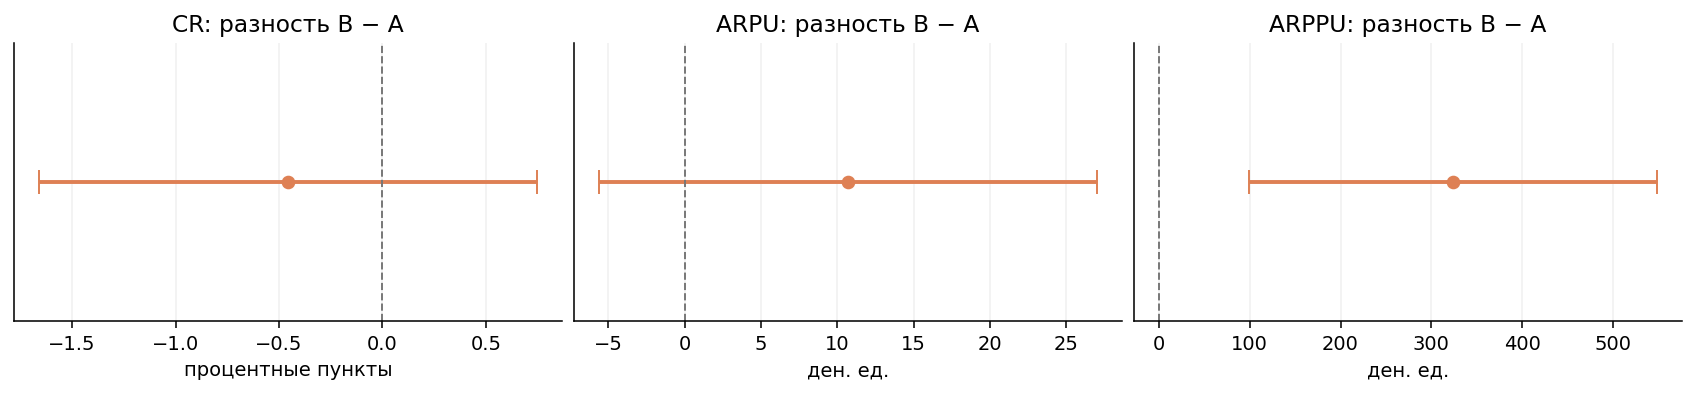

In [10]:
test_results = compare_metrics(users, alpha=ALPHA)

def present_tests(results):
    rows = []
    for metric, row in results.iterrows():
        scale = 100 if metric == "cr" else 1
        unit = "п.п." if metric == "cr" else "ден. ед."
        rows.append({"Метрика": metric.upper(), "B − A": round(row["difference"] * scale, 3),
                     "Единица": unit, "Изменение, %": round(row["relative_lift_pct"], 2),
                     "95% ДИ B − A": f"[{row['ci_low'] * scale:.3f}; {row['ci_high'] * scale:.3f}]",
                     "p-value": round(row["p_value"], 6), "p Холма": round(row["p_holm"], 6),
                     "Значимо после Холма": "Да" if row["significant_holm"] else "Нет"})
    return pd.DataFrame(rows).set_index("Метрика")

display(present_tests(test_results))

fig, axes = plt.subplots(1, 3, figsize=(12, 2.7), constrained_layout=True)
for ax, metric in zip(axes, ["cr", "arpu", "arppu"]):
    row = test_results.loc[metric]
    scale = 100 if metric == "cr" else 1
    delta, low, high = row[["difference", "ci_low", "ci_high"]].astype(float) * scale
    ax.errorbar(delta, 0, xerr=[[delta - low], [high - delta]], fmt="o",
                color=COLORS["B"], capsize=6, linewidth=2)
    ax.axvline(0, color="#777777", linestyle="--", linewidth=1)
    ax.set_title(f"{metric.upper()}: разность B − A")
    ax.set_xlabel("процентные пункты" if metric == "cr" else "ден. ед.")
    ax.set_yticks([])
    ax.set_ylim(-1, 1)
    ax.grid(axis="x", alpha=0.18)
plt.show()

**CR:** `p = 0,4455`; значимого изменения не выявлено. Интервал разности от −1,661 до +0,749 п.п.
Неотклонение H₀ не доказывает равенство конверсий и не доказывает отсутствие ухудшения.

**ARPU:** `p = 0,1984`; после Холма `p = 0,3969`. Интервал разности **[−5,62; +27,04]**
содержит ноль: основной показатель не даёт достаточных оснований для массового запуска.

**ARPPU:** `p = 0,0051`; после Холма `p = 0,0152`. Наблюдаемая разность средних среди плательщиков
значима, 95% интервал **[+99,64; +548,94]**. Это характеристика отобранных плательщиков,
а не доказательство причинного роста выручки у всех назначенных пользователей.

### 1.6. Проверка денежных показателей с помощью bootstrap

20 000 раз независимо выбираем пользователей с возвращением внутри A и B и считаем разность
средних **B − A**. Для ARPU в перевыборке сохранены неоплатившие пользователи с нулями.
Для ARPPU перевыборка производится внутри подмножеств плательщиков.
2,5-й и 97,5-й процентили дают 95% percentile-интервал. Здесь bootstrap используется для
интервала, а не для получения p-value из нецентрированного распределения разностей.
Описание метода: [SciPy — bootstrap](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.bootstrap.html).

In [11]:
def bootstrap_mean_difference(a, b, n_resamples=20000, seed=42, alpha=0.05, batch=128):
    """Независимый непараметрический bootstrap разности средних B − A."""
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    if min(len(a), len(b), n_resamples, batch) < 1 or not 0 < alpha < 1:
        raise ValueError("Проверьте выборки и параметры bootstrap.")
    rng = np.random.default_rng(seed)
    differences = np.empty(n_resamples)
    # Обрабатываем небольшие пакеты, чтобы не хранить все перевыборки в памяти.
    for start in range(0, n_resamples, batch):
        size = min(batch, n_resamples - start)
        mean_a = a[rng.integers(0, len(a), size=(size, len(a)))].mean(axis=1)
        mean_b = b[rng.integers(0, len(b), size=(size, len(b)))].mean(axis=1)
        differences[start:start + size] = mean_b - mean_a
    return differences, np.quantile(differences, [alpha / 2, 1 - alpha / 2])

In [12]:
a = users.loc[users["grp"] == "A", "rev"].to_numpy()
b = users.loc[users["grp"] == "B", "rev"].to_numpy()
bootstrap_rows = []
for metric, values_a, values_b in [("ARPU", a, b), ("ARPPU", a[a > 0], b[b > 0])]:
    differences, interval = bootstrap_mean_difference(
        values_a, values_b, n_resamples=N_BOOTSTRAP, seed=SEED, alpha=ALPHA
    )
    bootstrap_rows.append({"Метрика": metric, "Нижняя граница 95% ДИ": interval[0],
                           "Верхняя граница 95% ДИ": interval[1],
                           "Интервал включает ноль": bool(interval[0] <= 0 <= interval[1])})
display(pd.DataFrame(bootstrap_rows).set_index("Метрика").round(3))

,Нижняя граница 95% ДИ,Верхняя граница 95% ДИ,Интервал включает ноль
Метрика,,,
ARPU,-6.0080,26.7240,True
ARPPU,95.7390,537.6540,False


Bootstrap согласуется с основным анализом: интервал ARPU **[−6,01; +26,72]** включает ноль,
интервал ARPPU **[+95,74; +537,65]** положителен. Проверка формы распределения не меняет решения.

### 1.7. Чувствительность к составу анализируемой выборки

Включаем **всех 74 576 назначенных пользователей**, все 541 записи об оплатах и нулевую выручку остальных.
Это расчёт по назначениям (ITT при условии единого периода наблюдения для всех участников).
Он позволяет не исключать 149 плательщиков вне `active_studs` и проверить устойчивость вывода.
Даты назначения и длительность наблюдения в CSV отсутствуют, поэтому указанное условие
нельзя проверить непосредственно.

In [13]:
all_users, all_audit = build_user_data(groups_all, active, checks, cohort="all")
all_metrics = calculate_metrics(all_users)
all_tests = compare_metrics(all_users, alpha=ALPHA)
display(present_metrics(all_metrics))
display(present_tests(all_tests))
assert len(all_users) == groups_all["id"].nunique()
assert all_users["paid"].sum() == checks["id"].nunique()
assert np.isclose(all_users["rev"].sum(), checks["rev"].sum())

,Пользователи,Плательщики,Выручка,"CR, %",ARPU,ARPPU
grp,,,,,,
A,14693,107,"92,096.0000",0.7282,6.2680,860.7103
B,59883,434,"481,230.0036",0.7247,8.0362,"1,108.8249"


,B − A,Единица,"Изменение, %",95% ДИ B − A,p-value,p Холма,Значимо после Холма
Метрика,,,,,,,
CR,-0.0030,п.п.,-0.4800,[-0.157; 0.150],0.9644,0.9644,Нет
ARPU,1.7680,ден. ед.,28.2100,[-0.097; 3.633],0.0632,0.1263,Нет
ARPPU,248.1150,ден. ед.,28.8300,[77.137; 419.093],0.0047,0.0142,Да


По всем назначениям ARPU составляет **6,27 в A и 8,04 в B**, разность +1,77 (+28,21%).
`p = 0,0632`, после Холма `p = 0,1263`; 95% интервал **[−0,10; +3,63]** содержит ноль.
CR почти одинаков: 0,7282% и 0,7247%, `p = 0,9644`.
Таким образом, включение оплат вне списка активных не даёт статистически подтверждённого роста ARPU.
Эта проверка является анализом чувствительности, а не выбором более удобного p-value.

### 1.8. Ответ на бизнес-вопрос

**Не рекомендую запускать новую механику на всех пользователей по результатам этого эксперимента.**

1. Основная метрика ARPU выросла в наблюдаемых данных, но доверительный интервал допускает
   как снижение, так и рост. Это верно и для активных, и для всех назначенных пользователей.
2. Увеличение ARPPU статистически значимо, однако показатель рассчитан только среди плательщиков.
   Оно связано с изменением распределения оплат, в том числе с большой долей значений около 1900 в B.
3. Необходимо объяснить 149 оплат вне списка активных и разную долю активности по группам.
   Отсутствуют данные о показе механики, тарифах и датах наблюдения, чтобы проверить эти причины.

Следующий шаг: проверить журнал посещений и платежей, а затем провести новый эксперимент
с заранее выбранными ARPU, допустимым снижением CR, минимально полезным эффектом,
размером выборки и сроком завершения. Текущий результат не доказывает ни пользу, ни бесполезность механики.

## Задание 2. SQL: сегментация клиентов

Расчёт выполняется **на конец 31 марта 2024 года**. Все временные фильтры используют
верхнюю границу `< 2024-04-01 00:00:00`, чтобы включить события за весь день 31 марта.

| Сегмент | Правило |
|---|---|
| Постоянный | 3 и более доставленных заказов |
| Разовый | 1–2 доставленных заказа |
| Неактивный | 0 доставленных заказов, регистрация более 30 календарных дней назад |
| Новый | 0 доставленных заказов, регистрация 30 или менее календарных дней назад |

Запрос рассчитан на **PostgreSQL** и таблицы из задания: `customers`, `orders`, `customer_actions`.
Заказ учитывается только при статусе `Delivered` и фактической доставке до верхней границы среза.
События `Purchase` считаются отдельно как события, без `DISTINCT order_id` и без ограничения
на доставленные заказы. Агрегирование до `JOIN` предотвращает перемножение заказов и событий.

Город `NULL` сохраняется. Для клиента без доставок `orders_count = 0`,
а `avg_delivery_days = NULL`, поскольку среднее не определено.
Формула дробного количества дней:
[PostgreSQL — Date/Time Functions](https://www.postgresql.org/docs/current/functions-datetime.html).

In [14]:
sql_query = r"""
-- PostgreSQL. Срез на конец 31 марта 2024 года.
-- Заказы и события сначала агрегируются отдельно: JOIN не завышает счётчики.
WITH params AS (
    SELECT DATE '2024-03-31' AS as_of_date
),
delivered_orders AS (
    SELECT
        o.customer_id,
        COUNT(*) AS orders_count,
        AVG(
            EXTRACT(EPOCH FROM (
                o.order_delivered_customer_time - o.order_created_time
            )) / 86400.0
        ) AS avg_delivery_days
    FROM orders AS o
    CROSS JOIN params AS p
    WHERE o.order_status = 'Delivered'
      AND o.order_created_time < p.as_of_date + INTERVAL '1 day'
      AND o.order_delivered_customer_time < p.as_of_date + INTERVAL '1 day'
    GROUP BY o.customer_id
),
purchase_events AS (
    SELECT
        ca.customer_id,
        COUNT(*) AS purchase_events_count
    FROM customer_actions AS ca
    CROSS JOIN params AS p
    WHERE ca.event_type = 'Purchase'
      AND ca.event_timestamp < p.as_of_date + INTERVAL '1 day'
    GROUP BY ca.customer_id
),
customer_metrics AS (
    SELECT
        c.customer_id,
        c.customer_city,
        c.created_at::date AS registration_date,
        p.as_of_date - c.created_at::date AS days_since_registration,
        COALESCE(d.orders_count, 0) AS orders_count,
        COALESCE(pe.purchase_events_count, 0) AS purchase_events_count,
        d.avg_delivery_days
    FROM customers AS c
    CROSS JOIN params AS p
    LEFT JOIN delivered_orders AS d ON d.customer_id = c.customer_id
    LEFT JOIN purchase_events AS pe ON pe.customer_id = c.customer_id
    WHERE c.created_at < p.as_of_date + INTERVAL '1 day'
)
SELECT
    customer_id,
    customer_city,
    registration_date,
    days_since_registration,
    orders_count,
    purchase_events_count,
    avg_delivery_days,
    CASE
        WHEN orders_count >= 3 THEN 'Постоянный'
        WHEN orders_count BETWEEN 1 AND 2 THEN 'Разовый'
        WHEN orders_count = 0 AND days_since_registration > 30 THEN 'Неактивный'
        WHEN orders_count = 0 AND days_since_registration <= 30 THEN 'Новый'
    END AS segment
FROM customer_metrics
ORDER BY customer_id;
"""

**Границы проверены по условиям:** регистрация 1 марта даёт 30 дней и сегмент «Новый»
при отсутствии доставок; 29 февраля — 31 день и «Неактивный».
Одна или две доставки дают «Разовый», три — «Постоянный» независимо от срока регистрации.
Доставка или покупка ровно 1 апреля не учитывается; новый клиент, зарегистрированный
после 31 марта, в срез не попадает.

Выгрузки этих трёх SQL-таблиц не предоставлены, поэтому фактический результат запроса
в Redash не получен. Готовый текст также находится в `customer_segmentation.sql`.

## Задание 3. Python: автоматизация

### 3.1. Загрузка дополнительного файла и пересчёт метрик

`update_metrics()` принимает пути к CSV или DataFrame, автоматически определяет разделитель
и распространённые названия столбцов. Для произвольных заголовков предусмотрен `column_maps`.
Параметр `cohort` выбирает активных (`active`) или всех назначенных (`all`).

Повторная загрузка того же назначения не увеличивает выборку; назначение пользователя в обе группы
вызывает ошибку. Несколько оплат агрегируются по пользователю. При отсутствии плательщиков
ARPPU равен `NaN`, при отсутствии пользователей не определены CR и ARPU.
Общие функции `combine_groups`, `build_user_data`, `calculate_metrics` определены в задании 1.

In [15]:
def read_csv_flexible(source, sep=None):
    """Прочитать CSV с определением разделителя или скопировать DataFrame."""
    if isinstance(source, pd.DataFrame):
        return source.copy()
    path = Path(source)
    if sep is None:
        with path.open(encoding="utf-8-sig", newline="") as stream:
            sample = stream.read(8192)
        try:
            sep = csv.Sniffer().sniff(sample, delimiters=",;\t|").delimiter
        except csv.Error:
            # В одноколоночном active_studs разделителя может не быть.
            sep = ","
    return pd.read_csv(path, sep=sep, encoding="utf-8-sig")


def normalize_columns(frame, kind, column_map=None):
    """Привести заголовки к id/grp/rev; column_map: исходное имя → стандартное."""
    aliases = {
        "id": {"id", "student_id", "user_id", "uid", "customer_id"},
        "grp": {"grp", "group", "ab_group", "test_group", "experiment_group"},
        "rev": {"rev", "revenue", "amount", "payment"},
    }
    required = {"groups": ["id", "grp"], "active": ["id"],
                "checks": ["id", "rev"]}[kind]
    frame = frame.copy()
    if column_map:
        absent = set(column_map) - set(frame.columns)
        if absent:
            raise ValueError(f"Нет столбцов, указанных в column_map: {sorted(absent)}")
        frame = frame.rename(columns=column_map)
    frame.columns = [str(col).strip().lower() for col in frame.columns]
    if frame.columns.duplicated().any():
        raise ValueError("После нормализации появились повторяющиеся заголовки.")
    rename = {}
    for target in required:
        candidates = [col for col in frame.columns if col in aliases[target]]
        if len(candidates) != 1:
            raise ValueError(
                f"Нельзя однозначно определить {target!r}: {candidates}. "
                "Передайте явный column_map."
            )
        rename[candidates[0]] = target
    frame = frame.rename(columns=rename)[required]
    if frame.isna().any().any():
        raise ValueError(f"Пропуски в обязательных полях таблицы {kind}.")

    ids = pd.to_numeric(frame["id"], errors="raise")
    if (not np.isfinite(ids).all() or (ids <= 0).any()
            or (ids % 1 != 0).any() or (ids > np.iinfo(np.int64).max).any()):
        raise ValueError("Идентификаторы должны быть положительными целыми числами.")
    frame["id"] = ids.astype("int64")
    if kind == "groups":
        frame["grp"] = frame["grp"].astype(str).str.strip().str.upper()
        if not frame["grp"].isin(["A", "B"]).all():
            raise ValueError("Допустимы только группы A и B.")
    elif kind == "checks":
        frame["rev"] = pd.to_numeric(frame["rev"], errors="raise")
        if not np.isfinite(frame["rev"]).all() or frame["rev"].lt(0).any():
            raise ValueError("Ожидается конечная неотрицательная выручка.")
    return frame

In [16]:
def update_metrics(groups, active_studs, checks, additional_path=None, *,
                   column_maps=None, separators=None, cohort="active",
                   unknown_users="raise"):
    """Загрузить дополнительный CSV и пересчитать метрики.

    Источники: путь к CSV или DataFrame. additional_path=None означает расчёт
    без дополнения. column_maps и separators — словари с ключами groups,
    active, checks, additional. Произвольные заголовки задаются соответствием
    {исходное_имя: стандартное_имя}. cohort='all' включает всех назначенных.
    Неизвестные группы по умолчанию вызывают ошибку; exclude нужен для явно
    обозначенного сравнения с неполной исходной выгрузкой.

    Результат: словарь metrics, users, groups, audit.
    """
    column_maps = {} if column_maps is None else column_maps
    separators = {} if separators is None else separators

    def load(source, key, kind):
        raw = read_csv_flexible(source, sep=separators.get(key))
        return normalize_columns(raw, kind, column_maps.get(key))

    base = load(groups, "groups", "groups")
    active = load(active_studs, "active", "active")
    payments = load(checks, "checks", "checks")
    extra = (None if additional_path is None
             else load(additional_path, "additional", "groups"))
    combined = combine_groups(base, extra)
    users, audit = build_user_data(combined, active, payments, cohort, unknown_users)
    audit["added_users"] = len(combined) - base["id"].nunique()
    return {"metrics": calculate_metrics(users), "users": users,
            "groups": combined, "audit": audit}

In [17]:
# Только для сравнения с исходной неполной выгрузкой явно исключаем неизвестные ID.
before = update_metrics(paths["groups"], paths["active"], paths["checks"],
                        unknown_users="exclude")
after = update_metrics(paths["groups"], paths["active"], paths["checks"],
                       additional_path=paths["additional"])

display(pd.concat({"До дополнения": present_metrics(before["metrics"]),
                   "После дополнения": present_metrics(after["metrics"])},
                  names=["Расчёт", "Группа"]))
display(pd.DataFrame({"До дополнения": before["audit"], "После дополнения": after["audit"]}))
pd.testing.assert_frame_equal(after["metrics"], metrics)
print("Результат функции совпадает с основным анализом.")

Пользователи  Плательщики      Выручка  CR, %  \
Расчёт           Группа                                                  
До дополнения    A               1535           78  72,820.0000 5.0814   
                 B               6793          313 393,074.0035 4.6077   
После дополнения A               1538           78  72,820.0000 5.0715   
                 B               6803          314 394,974.0035 4.6156   

                           ARPU      ARPPU  
Расчёт           Группа                     
До дополнения    A      47.4397   933.5897  
                 B      57.8646 1,255.8275  
После дополнения A      47.3472   933.5897  
                 B      58.0588 1,257.8790

,До дополнения,После дополнения
assigned_users,"74,484.0000","74,576.0000"
active_users_in_file,"8,341.0000","8,341.0000"
cohort_users,"8,328.0000","8,341.0000"
unknown_active_users,13.0000,0.0000
unknown_payment_users,1.0000,0.0000
paying_users_outside_active,149.0000,149.0000
revenue_outside_active,"105,532.0001","105,532.0001"
added_users,0.0000,92.0000


Результат функции совпадает с основным анализом.


После загрузки дополнения активная выборка увеличивается с 8328 до 8341 пользователя.
В B добавляется одна оплата 1900. До дополнения 13 активных ID и один ID с оплатой
не имели известной группы; после дополнения таких ID нет. Это объясняет пересчёт знаменателей и выручки.

In [18]:
# Распространённые альтернативные заголовки определяются автоматически.
alternative_headers = additional.rename(columns={"id": "user_id", "grp": "group"})
alternative_result = update_metrics(groups, active, checks, alternative_headers)
pd.testing.assert_frame_equal(alternative_result["metrics"], after["metrics"])

# Пример произвольных заголовков: задаём явное соответствие.
custom_headers = additional.rename(columns={"id": "участник", "grp": "ветка"})
custom_result = update_metrics(
    groups, active, checks, custom_headers,
    column_maps={"additional": {"участник": "id", "ветка": "grp"}}
)
pd.testing.assert_frame_equal(custom_result["metrics"], after["metrics"])

# Повторное добавление файла не должно повторно включать тех же пользователей.
repeated = update_metrics(after["groups"], active, checks, paths["additional"])
pd.testing.assert_frame_equal(repeated["metrics"], after["metrics"])
assert repeated["audit"]["added_users"] == 0

# Дополнительный параметр меняет анализируемую выборку.
all_via_function = update_metrics(groups, active, checks, additional, cohort="all")
pd.testing.assert_frame_equal(all_via_function["metrics"], all_metrics)
print("Проверены альтернативные заголовки, повторная загрузка и cohort='all'.")

Проверены альтернативные заголовки, повторная загрузка и cohort='all'.


### 3.2. Графики по рассчитанным метрикам

`plot_metrics()` принимает таблицу метрик, список нужных показателей, размер рисунка
и необязательный путь сохранения. Возвращает `Figure` и массив `Axes` для дальнейшей настройки.

In [19]:
def plot_metrics(metrics, metric_names=("cr", "arpu", "arppu"), *,
                 figsize=None, save_path=None):
    """Построить сравнение A/B по рассчитанным метрикам; вернуть Figure и Axes.

    metrics — DataFrame из update_metrics(...)["metrics"].
    CR передаётся как доля и отображается в процентах. При отсутствии
    знаменателя выводится 'нет данных'. save_path задаёт необязательное сохранение.
    """
    labels = {"cr": ("Конверсия в оплату", "%"),
              "arpu": ("Выручка на пользователя", "ден. ед."),
              "arppu": ("Выручка на платящего", "ден. ед."),
              "users": ("Пользователи", "человек"),
              "payers": ("Платящие пользователи", "человек"),
              "revenue": ("Выручка", "ден. ед.")}
    metric_names = tuple(metric_names)
    if not metric_names or any(m not in labels or m not in metrics for m in metric_names):
        raise ValueError("Укажите непустой список доступных метрик.")
    frame = metrics.reindex(["A", "B"])
    fig, axes = plt.subplots(
        1, len(metric_names), figsize=figsize or (4.2 * len(metric_names), 4),
        squeeze=False, constrained_layout=True
    )
    colors = ["#537A99", "#DE8054"]
    for ax, metric in zip(axes.ravel(), metric_names):
        values = frame[metric].to_numpy(dtype=float) * (100 if metric == "cr" else 1)
        bars = ax.bar(["A", "B"], np.nan_to_num(values, nan=0), color=colors, width=0.55)
        ax.set_title(f"{metric.upper()} · {labels[metric][0]}", fontsize=11)
        ax.set_ylabel(labels[metric][1])
        top = np.nanmax(values) if np.isfinite(values).any() else 1
        ax.set_ylim(0, max(top * 1.22, 1))
        ax.grid(axis="y", alpha=0.18)
        ax.set_axisbelow(True)
        ax.spines[["top", "right"]].set_visible(False)
        for bar, value in zip(bars, values):
            label = "нет данных" if not np.isfinite(value) else f"{value:,.2f}"
            ax.annotate(label, (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                        xytext=(0, 6), textcoords="offset points", ha="center", fontsize=10)
    if save_path is not None:
        fig.savefig(save_path, dpi=160, bbox_inches="tight")
    return fig, axes.ravel()

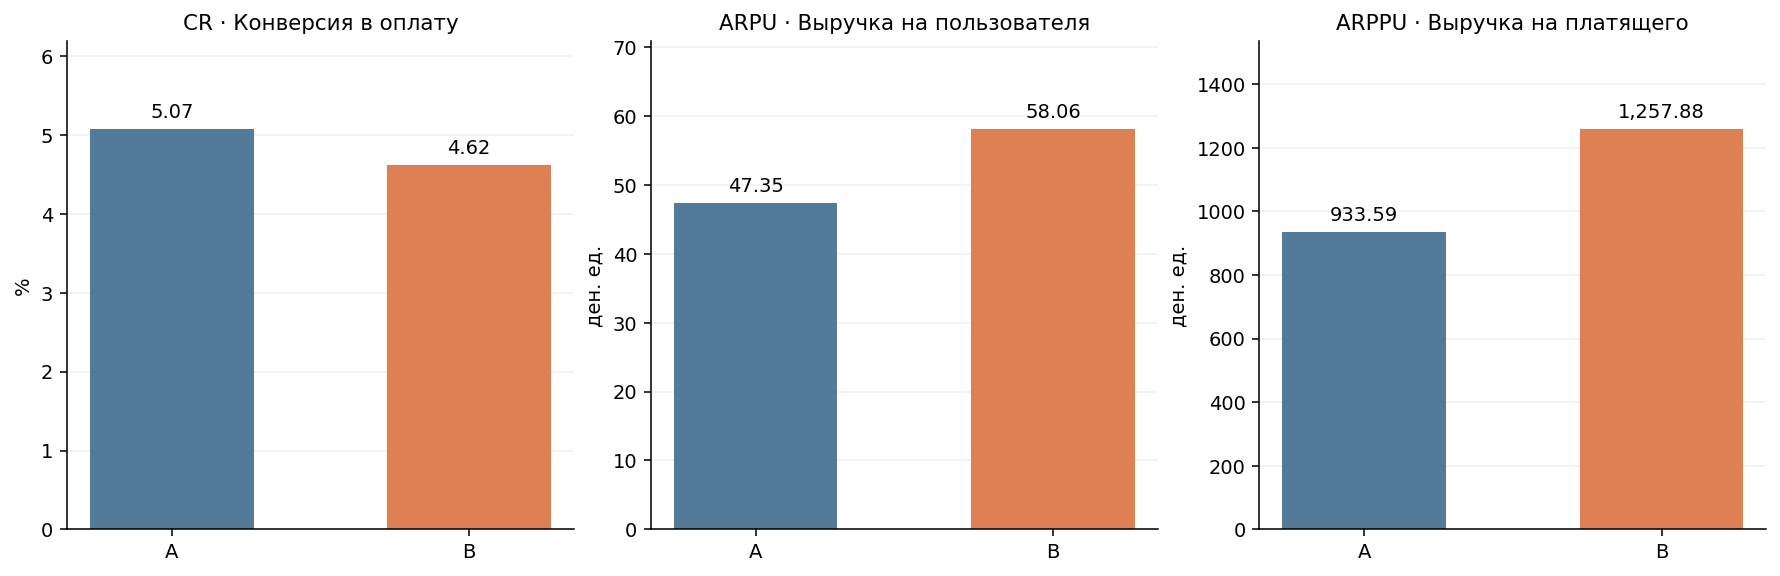

In [20]:
fig, axes = plot_metrics(after["metrics"], metric_names=("cr", "arpu", "arppu"))
plt.show()

# Пример сохранения при необходимости:
# plot_metrics(after["metrics"], save_path="metrics.png")

Notebook содержит все определения функций и выполняется самостоятельно при наличии CSV.
Для повторного использования в других проектах эти же функции вынесены в `project_functions.py`.